# Milestone 2

In [2]:
import os
import glob
import numpy as np
import pandas as pd
from tqdm import tqdm
import librosa
import librosa.display
import matplotlib.pyplot as plt
import random
import torch

import warnings
warnings.filterwarnings("ignore")

In [7]:
#----------------------------- DON'T CHANGE THIS --------------------------
DATA_SEED = 67
TRAINING_SEED = 1234
SR = 22050
DURATION = 5.0
N_FFT = 2048
HOP_LENGTH = 512
N_MELS = 128
TOP_DB=20
TARGET_SNR_DB = 10

random.seed(DATA_SEED)
np.random.seed(DATA_SEED)
torch.manual_seed(DATA_SEED)
torch.cuda.manual_seed(DATA_SEED)

In [8]:
# CONFIGURATION
DATA_ROOT = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup"# Enter dataset path
GENRES = sorted(os.listdir(os.path.join(DATA_ROOT, "genres_stems"))) # Make the list of all genres available (alphabetical order)
STEMS = ["drums.wav", "vocals.wav", "bass.wav", "other.wav"] # Write here stems file name
STEM_KEYS = ['drums', 'vocals', 'bass', 'other']
GENRE_TO_TEST = 'rock'

In [9]:
def build_dataset(root_dir, val_split=0.17, seed=42):
    # Initialize empty dictionaries
    train_dataset = {g: {s.replace('.wav', ''): [] for s in STEMS} for g in GENRES}
    val_dataset   = {g: {s.replace('.wav', ''): [] for s in STEMS} for g in GENRES}

    rng = random.Random(seed)

    # ------------------- write your code here -------------------------------
    total_corrupted = 0
    total_less_50491 = 0
    total_greater_50493 = 0

    for genre in GENRES:
        # Iterate through Genres
        genre_path = os.path.join(root_dir, "genres_stems", genre)
        # Check: if genre folder exists
        if not os.path.exists(genre_path):
            continue
        # CHECK : Completeness (Does it have all stems?)
        songs = sorted(os.listdir(genre_path))
        valid_songs = []
        for song in songs:
            song_path = os.path.join(genre_path, song)
            if not os.path.isdir(song_path):
                continue
            if not all(os.path.exists(os.path.join(song_path, stem)) for stem in STEMS):
                continue
            corrupted = False
        # CHECK : Corruption (Is any file too small? (less than 4kb))
        # size checks
            for stem in STEMS:
                file_path = os.path.join(song_path, stem)
                size = os.path.getsize(file_path)

                # < 4KB corruption
                if size < 4 * 1024:
                    total_corrupted += 1
                    corrupted = True

                # Size conditions
                if size < 5.0491 * 1024 * 1024:
                    total_less_50491 += 1

                if size > 5.0493 * 1024 * 1024:
                    total_greater_50493 += 1

            if not corrupted:
                valid_songs.append(song_path)

        rng.shuffle(valid_songs)

        split_idx = int(len(valid_songs) * (1 - val_split))

        train_songs = valid_songs[:split_idx]
        val_songs   = valid_songs[split_idx:]
        # Stratified Shuffle Split
     #-------------------------------------------------------------------------

        # Helper function to populate dict
        def add_to_dict(target_dict, song_list):
            for song_path in song_list:
                for stem in STEMS:
                    stem_name = stem.replace(".wav", "")
                    target_dict[genre][stem_name].append(
                        os.path.join(song_path, stem)
                    )

        add_to_dict(train_dataset, train_songs)
        add_to_dict(val_dataset, val_songs)

    return train_dataset, val_dataset

tr, val = build_dataset(DATA_ROOT)

## What is the mean duration (in seconds) of the Jazz genre stems in train dataset?

In [11]:
import librosa
import numpy as np

jazz_durations = []

for stem_name, file_list in tr["jazz"].items():
    for file_path in file_list:
        try:
            y, sr = librosa.load(file_path, sr=None)
            duration = librosa.get_duration(y=y, sr=sr)
            jazz_durations.append(duration)
        except Exception as e:
            print(f"Error loading {file_path}: {e}")

mean_duration = np.mean(jazz_durations)

print("Total Jazz stems in train:", len(jazz_durations))
print("Mean duration (seconds):", mean_duration)

Total Jazz stems in train: 332
Mean duration (seconds): 30.034636505204485


## What are the unique sample rates present in the entire dataset? (consider genre stems, noise data and mashups) Enter your answer as a comma separated list. Example: [40000, 50000, 60000]

In [3]:
ROOT_PATH = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup"

folders_to_check = [
    "genres_stems",
    "ESC-50-master/audio",
    "mashups"
]

unique_sample_rates = set()

for folder in folders_to_check:
    folder_path = os.path.join(ROOT_PATH, folder)

    for root, _, files in os.walk(folder_path):
        for file in files:
            if file.endswith(".wav"):
                file_path = os.path.join(root, file)
                try:
                    # sr=None → preserves original sample rate
                    y, sr = librosa.load(file_path, sr=None)
                    unique_sample_rates.add(sr)
                except Exception as e:
                    print(f"Error reading {file_path}: {e}")

print(sorted(list(unique_sample_rates)))

[22050, 44100]


## How many empty or zero-byte audio files are present in the train dataset?

In [4]:
zero_byte_count = 0
zero_files = []

for root, _, files in os.walk(ROOT_PATH):
    for file in files:
        if file.endswith(".wav"):
            file_path = os.path.join(root, file)
            
            # Check file size
            if os.path.getsize(file_path) == 0:
                zero_byte_count += 1
                zero_files.append(file_path)

print("Total zero-byte audio files:", zero_byte_count)

Total zero-byte audio files: 0


## What is the average peak amplitude (in dB) for vocal stems in train dataset?

In [34]:
vocal_peaks_db = []

for genre in tr:
    if "vocals" in tr[genre]:
        for file_path in tr[genre]["vocals"]:
            try:
                y, sr = librosa.load(file_path, sr=None)

                peak = np.max(np.abs(y))

                # Avoid log(0)
                if peak > 0:
                    peak_db = 20 * np.log10(peak)
                    vocal_peaks_db.append(peak_db)

            except:
                continue

mean_peak_db = np.mean(vocal_peaks_db)

print("Average Peak Amplitude dB for Vocal Stems:", mean_peak_db)

Average Peak Amplitude dB for Vocal Stems: -12.423471


## What is the mean spectral centroid for 'blues' genre in the train dataset?

In [33]:
spectral_centroids = []

for stem_name in tr["blues"]:
    for file_path in tr["blues"][stem_name]:
        try:
            y, sr = librosa.load(file_path, sr=None)

            # Compute spectral centroid
            centroid = librosa.feature.spectral_centroid(y=y, sr=sr)

            # Take mean over time frames
            spectral_centroids.append(np.mean(centroid))

        except Exception as e:
            print(f"Error processing {file_path}: {e}")

# Mean over all blues stems
mean_spectral_centroid = np.mean(spectral_centroids)

print("Mean Spectral Centroid Blues in Train dataset:", mean_spectral_centroid)

Mean Spectral Centroid Blues in Train dataset: 2324.4457217291647


## Which genre in the train dataset has the highest mean spectral centroid?

In [17]:
genre_centroid_means = {}

for genre in tr:
    spectral_centroids = []

    for stem_name in tr[genre]:
        for file_path in tr[genre][stem_name]:
            try:
                y, sr = librosa.load(file_path, sr=None)

                centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
                spectral_centroids.append(np.mean(centroid))

            except:
                continue

    if len(spectral_centroids) > 0:
        genre_centroid_means[genre] = np.mean(spectral_centroids)

# Find genre with highest mean spectral centroid
highest_genre = max(genre_centroid_means, key=genre_centroid_means.get)

print("Mean Spectral Centroid per Genre:")
for g, val in genre_centroid_means.items():
    print(f"{g}: {val}")

print("\nGenre with Highest Mean Spectral Centroid:")
print(highest_genre)


Mean Spectral Centroid per Genre:
blues: 2324.4457217291647
classical: 1693.667810231609
country: 2259.747938595377
disco: 2457.6087049040075
hiphop: 2360.9420468879434
jazz: 2512.5898863780035
metal: 2597.310287025006
pop: 2452.749637282946
reggae: 2389.2453875850433
rock: 2267.178629933886

Genre with Highest Mean Spectral Centroid:
metal


## How many stem audio files in the train dataset contain silence in the first 0.5 seconds? 

In [18]:
silence_count = 0
threshold = 1e-4   # very small amplitude

for genre in tr:
    for stem_name in tr[genre]:
        for file_path in tr[genre][stem_name]:
            try:
                # Load only first 0.5 seconds
                y, sr = librosa.load(file_path, sr=None, duration=0.5)

                # If max amplitude is extremely low → silence
                if np.max(np.abs(y)) < threshold:
                    silence_count += 1

            except:
                continue

print("Number of stem files with silence in first 0.5 seconds:", silence_count)

Number of stem files with silence in first 0.5 seconds: 274


In [32]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report

# --- 1. Setup and Preprocessing ---
ROOT = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup'
STEMS_PATH = os.path.join(ROOT, 'genres_stems')
GENRES = ["blues", "classical", "country", "disco", "hiphop", "jazz", "metal", "pop", "reggae", "rock"]

def extract_features(song_path):
    # Load 10s at 22050Hz
    y, sr = librosa.load(os.path.join(song_path, 'other.wav'), sr=22050, duration=10)
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    spec_cent = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    zcr = np.mean(librosa.feature.zero_crossing_rate(y))
    rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
    return [float(tempo), spec_cent, zcr, rolloff]

# --- 2. Data Preparation & Stratified Split ---
data = []
for g in GENRES:
    gp = os.path.join(STEMS_PATH, g)
    songs = [s for s in os.listdir(gp) if os.path.isdir(os.path.join(gp, s))]
    for s in songs[:50]: # Sampling 50 for speed; use all for final
        data.append({'path': os.path.join(gp, s), 'genre': g})

df = pd.DataFrame(data)
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['genre'], random_state=42)

# --- 3. Model Training (Decision Tree) ---
X_train = np.array([extract_features(p) for p in train_df['path']])
y_train = train_df['genre']
X_val = np.array([extract_features(p) for p in val_df['path']])
y_val = val_df['genre']

clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)


y_pred = clf.predict(X_val)

macro_f1 = f1_score(y_val, y_pred, average='macro')

cm = confusion_matrix(y_val, y_pred, labels=GENRES)

cr = classification_report(y_val, y_pred, target_names=GENRES, output_dict=True)

accuracy = np.mean(y_pred == y_val)


print("Detailed Classification Report:")
print(cr)

Detailed Classification Report:
{'blues': {'precision': 0.2, 'recall': 0.1, 'f1-score': 0.13333333333333333, 'support': 10.0}, 'classical': {'precision': 0.14285714285714285, 'recall': 0.1, 'f1-score': 0.11764705882352941, 'support': 10.0}, 'country': {'precision': 0.1, 'recall': 0.1, 'f1-score': 0.1, 'support': 10.0}, 'disco': {'precision': 0.2, 'recall': 0.4, 'f1-score': 0.26666666666666666, 'support': 10.0}, 'hiphop': {'precision': 0.25, 'recall': 0.1, 'f1-score': 0.14285714285714285, 'support': 10.0}, 'jazz': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 10.0}, 'metal': {'precision': 0.4090909090909091, 'recall': 0.9, 'f1-score': 0.5625, 'support': 10.0}, 'pop': {'precision': 0.2, 'recall': 0.2, 'f1-score': 0.2, 'support': 10.0}, 'reggae': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 10.0}, 'rock': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 10.0}, 'accuracy': 0.19, 'macro avg': {'precision': 0.15019480519480521, 'recall': 0.19, 'f

## What is the validation macro f1 score computed using above code?


In [28]:
print(f"Validation Macro F1 Score: {macro_f1:.4f}\n")

Validation Macro F1 Score: 0.1523



## What is the precision of hiphop?

In [29]:
print("\nPrecision of hiphop:", cr['hiphop']['precision'])


Precision of hiphop: 0.25


## What is the recall of pop?

In [30]:
print("Recall of pop:", cr['pop']['recall'])

Recall of pop: 0.2


## Enter model accuracy.


In [31]:
print(f"Model Accuracy: {accuracy:.4f}")

Model Accuracy: 0.1900


## Which genre has the highest true positives?

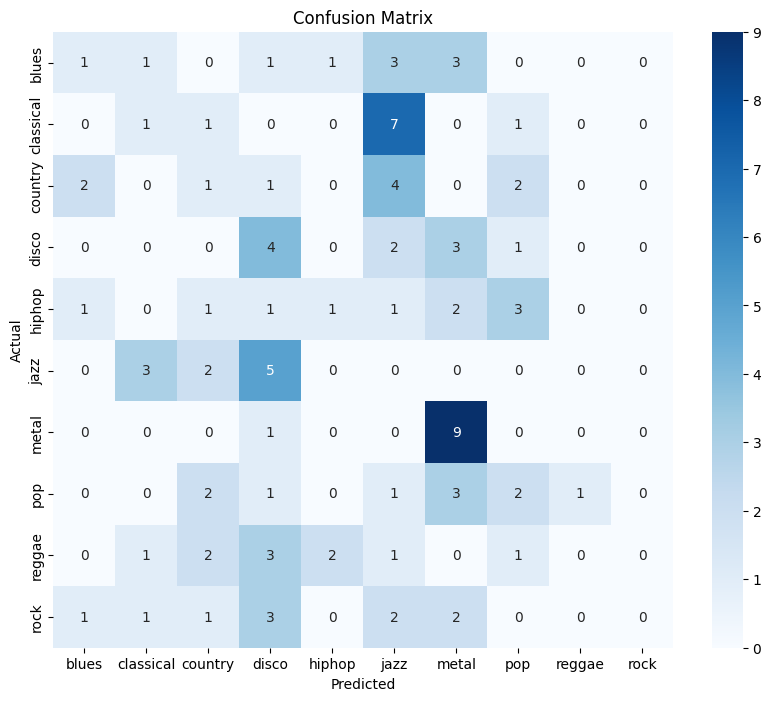

In [21]:
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=GENRES,
            yticklabels=GENRES,
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [25]:
tp_dict = {}
fn_dict = {}

for i, genre in enumerate(GENRES):
    TP = cm[i, i]
    FN = np.sum(cm[i, :]) - TP

    tp_dict[genre] = TP
    fn_dict[genre] = FN

In [26]:
highest_tp_genre = max(tp_dict, key=tp_dict.get)

print("Genre with Highest True Positives:", highest_tp_genre)
print("TP value:", tp_dict[highest_tp_genre])

Genre with Highest True Positives: metal
TP value: 9


In [27]:
lowest_fn_genre = min(fn_dict, key=fn_dict.get)

print("Genre with Lowest False Negatives:", lowest_fn_genre)
print("FN value:", fn_dict[lowest_fn_genre])

Genre with Lowest False Negatives: metal
FN value: 1
